# RT-DETR fire/smoke - hyperparameter probes

Cheap probes run before committing to the ~15 h stage-1 job. Every number here
comes from a real run on fixed 1,200-image / 300-image slices, so runs within a
group are directly comparable.

Regenerate with `python scripts/experiments.py`, then re-run this notebook.

**Read the caveats in each section** - the freeze probe answers a weaker
question than the one we actually care about, and the 1280-resolution long
probe never completed cleanly (see section 5).

**Decisions made from this data:** both stages now train at `imgsz=640,
batch=16, lr0=3e-4/3e-5`. Everything else tested (`cos_lr`, `close_mosaic`,
`mosaic`) came back as "keep the Ultralytics default".

**Two results were retracted on re-reading** (sections 5 and 8) -- both cases
where a setting that hurts early and pays off later looked bad in a truncated
probe. These probes are 1,200-3,000 images over 14-20 epochs; the real stage 1
is 85,783 images over 30. That regime difference systematically disadvantages
regularisers (mosaic) and extra capacity (higher resolution). See
`docs/DESIGN_DECISIONS.md` sec 5.8, and sec 7 for the cheap stage-2 A/B plan
that can actually settle them.

**Data loss note:** `imgsz_1280_dfire_long`'s partial results.csv (from its
second, 5-6-epoch timeout attempt) was accidentally deleted during suite
maintenance -- a probe rerun's cleanup step fired before a fix meant to
protect it was in place. The section 5 chart will show only 640/960 as a
result. The actual numbers observed before deletion are preserved in
`docs/DESIGN_DECISIONS.md` sec 5.4, written down before the data was lost.


## Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

EXP = Path.home() / "repos/fire_detection/runs/exp"
summary = pd.DataFrame(json.loads((EXP / "summary.json").read_text()))


def load(name):
    """One probe's per-epoch results.csv, with columns stripped of whitespace."""
    df = pd.read_csv(EXP / name / "results.csv")
    df.columns = [c.strip() for c in df.columns]
    return df


def total_train_loss(df):
    """RT-DETR reports three train losses; their sum is the quantity optimised."""
    return df["train/giou_loss"] + df["train/cls_loss"] + df["train/l1_loss"]


def total_val_loss(df):
    return df["val/giou_loss"] + df["val/cls_loss"] + df["val/l1_loss"]


plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
summary[["name", "group", "ok", "wall_s", "peak_vram_gb"]]

,name,group,ok,wall_s,peak_vram_gb
0,overfit,overfit,True,NaN,NaN
1,lr_3e-05,lr,True,NaN,NaN
2,lr_1e-04,lr,True,243.2,13.37
3,lr_3e-04,lr,True,268.7,13.69
4,lr_1e-03,lr,True,248.5,13.38
5,lr_3e-03,lr,True,247.0,13.38
6,imgsz_640,imgsz,True,335.3,4.70
7,imgsz_960,imgsz,True,535.8,7.27
8,imgsz_1280,imgsz,True,469.0,11.82
9,imgsz_640_dfire,imgsz_dfire,True,310.9,4.08


## 1. Pipeline check: overfit 16 images

The single most valuable check. A model that cannot memorise 16 images has a
broken pipeline somewhere.

A first version of this probe *appeared* to fail, for an instructive reason:
`accumulate = round(nbs/batch)` meant 16 images at batch 8 fired one optimizer
step every 4 epochs, so 60 epochs bought ~15 gradient steps. Fixed by pinning
`nbs=batch` (accumulate=1) and holding the LR flat with `lrf=1.0`.

total loss 7.810 -> 0.408  (94.8% reduction)


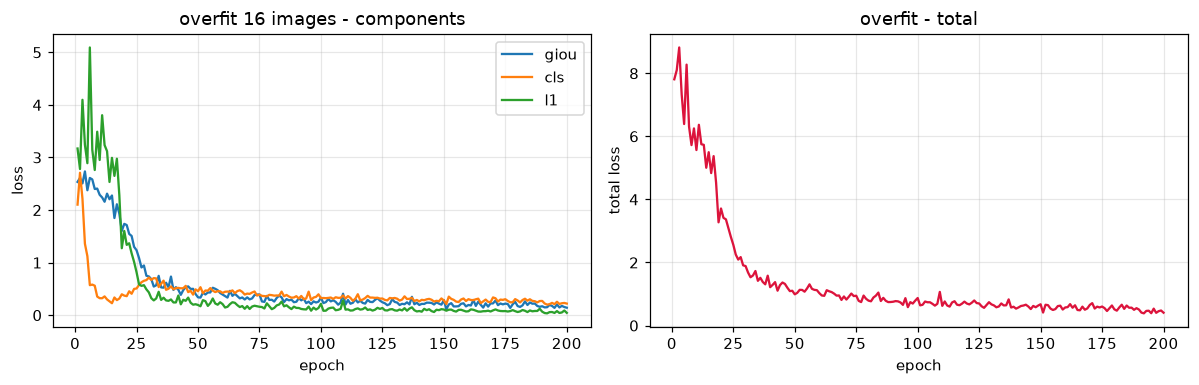

In [2]:
# Can the pipeline drive loss to ~zero on 16 images? If not, something is
# broken upstream (labels, class remap, loss, optimizer) and no amount of
# hyperparameter tuning matters.
df = load("overfit")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

for c, lbl in [("train/giou_loss", "giou"), ("train/cls_loss", "cls"), ("train/l1_loss", "l1")]:
    ax[0].plot(df["epoch"], df[c], label=lbl)
ax[0].set(xlabel="epoch", ylabel="loss", title="overfit 16 images - components")
ax[0].legend()

ax[1].plot(df["epoch"], total_train_loss(df), color="crimson")
ax[1].set(xlabel="epoch", ylabel="total loss", title="overfit - total")

plt.tight_layout()
first, last = total_train_loss(df).iloc[0], total_train_loss(df).iloc[-1]
print(f"total loss {first:.3f} -> {last:.3f}  ({100 * (1 - last / first):.1f}% reduction)")

## 2. Learning rate

`1e-4` is the DETR-family convention and what `train.py` currently uses.
Swept 3e-5 through 3e-3 (5 points, half a decade apart) to check it.

**Finding:** 3e-4 wins cleanly over 1e-4 on train loss, mAP50, and
generalisation gap simultaneously. 1e-3 is close behind. 3e-3 collapses --
worse than every other value including the original 3e-5, the classic shape
of an LR that's begun destabilising training. 3e-4 looks like a real local
optimum in this range, not a point on a still-climbing curve.

Probes use `warmup_epochs=0.5`, not the `3.0` default: warmup is
`max(round(warmup_epochs * iters), 100)` iterations, so at the default a
4-epoch probe would be almost entirely warmup and would compare ramps rather
than target LRs.

final-epoch mAP50 by LR:
  lr_3e-05   0.0059
  lr_1e-04   0.0151
  lr_3e-04   0.0654
  lr_1e-03   0.0490
  lr_3e-03   0.0035


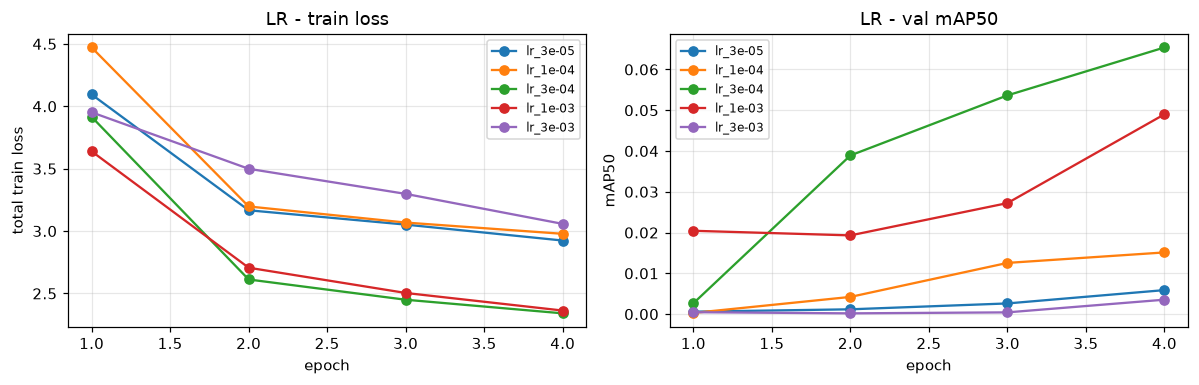

In [3]:
# Learning rate: 3e-5 / 1e-4 / 3e-4 / 1e-3 / 3e-3, all else fixed.
order = ["lr_3e-05", "lr_1e-04", "lr_3e-04", "lr_1e-03", "lr_3e-03"]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for name in order:
    if name not in set(summary.query("group == 'lr' and ok")["name"]):
        continue
    df = load(name)
    ax[0].plot(df["epoch"], total_train_loss(df), marker="o", label=name)
    ax[1].plot(df["epoch"], df["metrics/mAP50(B)"], marker="o", label=name)
ax[0].set(xlabel="epoch", ylabel="total train loss", title="LR - train loss")
ax[1].set(xlabel="epoch", ylabel="mAP50", title="LR - val mAP50")
for a in ax:
    a.legend(fontsize=8)
plt.tight_layout()

print("final-epoch mAP50 by LR:")
for name in order:
    if name not in set(summary.query("group == 'lr' and ok")["name"]):
        continue
    d = load(name)
    print(f"  {name:10} {d['metrics/mAP50(B)'].iloc[-1]:.4f}")

## 3. Resolution on FASDD (stage 1)

Batch fixed at 4 across all three resolutions so `imgsz` is the only variable
(4 is also the only batch that fits at 1280). `rtdetr-l.pt` was pretrained at
640 (confirmed in the checkpoint's `train_args`).

**Finding:** 640 wins on every metric. Since FASDD's own native images are
already close to 640 (median 718x540), this mostly reflects optimisation cost
rather than genuine detail loss -- but section 5 shows the same ranking holds
on D-Fire too, where detail loss *should* matter.

,name,wall_s,peak_vram_gb
6,imgsz_640,335.3,4.70
7,imgsz_960,535.8,7.27
8,imgsz_1280,469.0,11.82


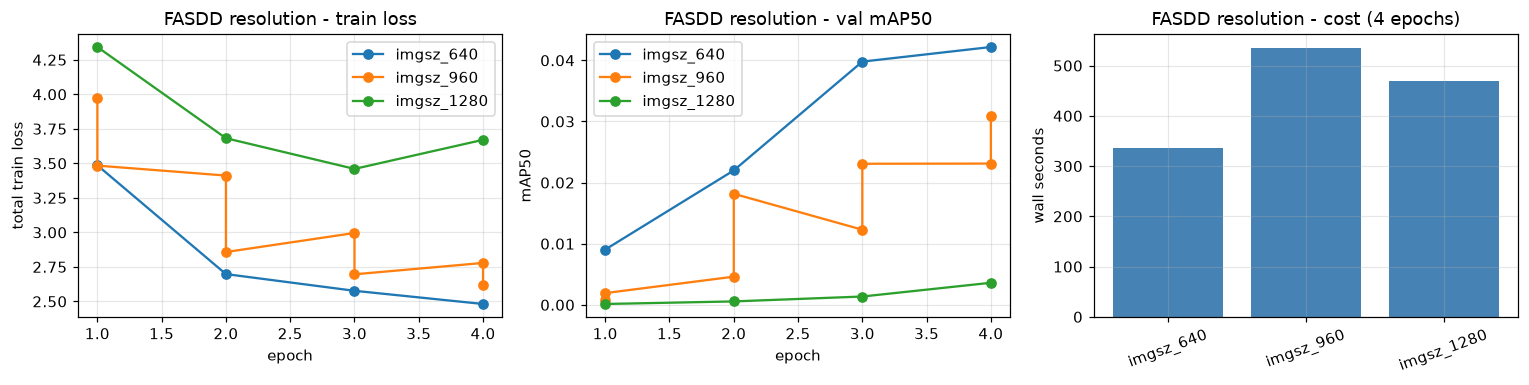

In [4]:
# Resolution on FASDD (stage-1 data), at FIXED batch=4 so imgsz is the only
# variable. FASDD's own native images are already close to 640 (median
# 718x540), so this mainly tests optimisation cost, not detail recovery.
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for name in summary.query("group == 'imgsz' and ok")["name"]:
    df = load(name)
    ax[0].plot(df["epoch"], total_train_loss(df), marker="o", label=name)
    ax[1].plot(df["epoch"], df["metrics/mAP50(B)"], marker="o", label=name)
ax[0].set(xlabel="epoch", ylabel="total train loss", title="FASDD resolution - train loss")
ax[1].set(xlabel="epoch", ylabel="mAP50", title="FASDD resolution - val mAP50")
for a in ax[:2]:
    a.legend()

sub = summary.query("group == 'imgsz' and ok")
ax[2].bar(sub["name"], sub["wall_s"], color="steelblue")
ax[2].set(ylabel="wall seconds", title="FASDD resolution - cost (4 epochs)")
ax[2].tick_params(axis="x", rotation=20)
plt.tight_layout()
sub[["name", "wall_s", "peak_vram_gb"]]

## 4. Resolution on D-Fire (stage 2), 4 epochs

Same design as section 3, run on D-Fire instead -- this is the probe that
actually tests the hypothesis that motivated 960 in the first place: D-Fire's
median native image (1200x720) is well above 640, so higher imgsz should have
real detail to recover.

**Finding:** 640 still wins clearly (mAP50 0.017 vs 960's 0.009 vs 1280's
0.0005). See section 5 for whether that holds given more epochs.

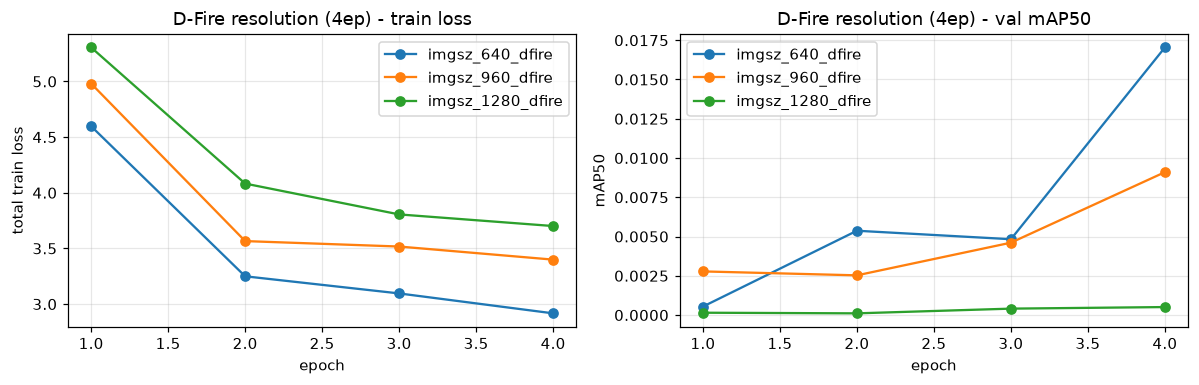

In [5]:
# Resolution on D-Fire (stage-2 data, 4 epochs) -- the probe that actually
# tests the native-resolution hypothesis: D-Fire's median native image is
# 1200x720, so 960/1280 should in principle recover detail 640 discards.
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for name in summary.query("group == 'imgsz_dfire' and ok")["name"]:
    df = load(name)
    ax[0].plot(df["epoch"], total_train_loss(df), marker="o", label=name)
    ax[1].plot(df["epoch"], df["metrics/mAP50(B)"], marker="o", label=name)
ax[0].set(xlabel="epoch", ylabel="total train loss", title="D-Fire resolution (4ep) - train loss")
ax[1].set(xlabel="epoch", ylabel="mAP50", title="D-Fire resolution (4ep) - val mAP50")
for a in ax:
    a.legend()
plt.tight_layout()

## 5. Resolution on D-Fire, extended to 14 epochs

4 epochs structurally favours whichever imgsz needs no adaptation (640).
Extended to see whether 960/1280 close the gap once that one-time adaptation
cost is paid off.

**Finding:** 640 and 960 both plateau by epoch ~4-5 and then just oscillate
in a stable band for the remaining 9-10 epochs -- no further improvement
either way. 640's band sits above 960's throughout. 1280 could not be
resolved cleanly: it timed out twice and its two partial attempts disagreed
substantially with each other at the same epochs, more consistent with high
measurement noise (only ~18 real optimizer steps/epoch at this batch/slice
size) than with a reproducible trend. **Decision: 640 for both stages**, on
the strength of 640/960's clean, mutually-consistent, fully-completed
comparison -- not on ruling 1280 out, which the data cannot actually do.

mAP50 trajectory shape (peak epoch -> final-10-epoch band):
  imgsz_640_dfire_long     n=14  peak=0.0532 @ epoch 5  final=0.0451
  imgsz_960_dfire_long     n=14  peak=0.0445 @ epoch 4  final=0.0271


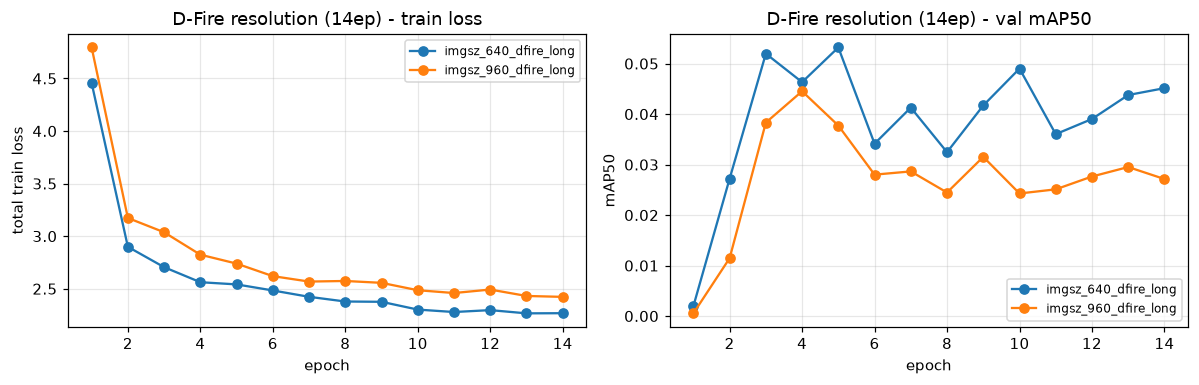

In [6]:
# Resolution on D-Fire at 14 epochs -- extended because the 4-epoch probe
# structurally favours whatever imgsz needs no adaptation (640, which is
# exactly what rtdetr-l.pt was pretrained at), and could not distinguish
# "640 just wins" from "960/1280 haven't paid off their adaptation cost yet".
#
# CAVEAT on imgsz_1280_dfire_long: it timed out TWICE (2700s then 5400s) and
# never completed 14 epochs. Its two partial attempts disagreed with each
# other at matching epochs (e.g. epoch 5 mAP50: 0.028 vs 0.0031) despite
# identical config and seed -- likely disk/CPU contention on the host rather
# than GPU compute (OOM and GPU thermal throttling were both checked and
# ruled out). Whichever partial run is plotted here should be read as noisy,
# not as a reliable trajectory.
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
# Deliberately NOT filtering on "ok" here: imgsz_1280_dfire_long's two
# attempts both timed out (ok=False), but their partial results.csv is the
# whole point of this section -- excluding it would silently hide the
# inconclusive-not-negative finding behind a misleading clean chart.
group_names = summary.query("group == 'imgsz_dfire_long'")["name"]
for name in group_names:
    csv = EXP / name / "results.csv"
    if not csv.exists():
        continue
    df = load(name)
    n = f"{name} ({len(df)}/14 epochs, timed out)" if len(df) < 14 else name
    ax[0].plot(df["epoch"], total_train_loss(df), marker="o", label=n)
    ax[1].plot(df["epoch"], df["metrics/mAP50(B)"], marker="o", label=n)
ax[0].set(xlabel="epoch", ylabel="total train loss", title="D-Fire resolution (14ep) - train loss")
ax[1].set(xlabel="epoch", ylabel="mAP50", title="D-Fire resolution (14ep) - val mAP50")
for a in ax:
    a.legend(fontsize=8)
plt.tight_layout()

print("mAP50 trajectory shape (peak epoch -> final-10-epoch band):")
for name in group_names:
    csv = EXP / name / "results.csv"
    if not csv.exists():
        continue
    d = load(name)["metrics/mAP50(B)"]
    flag = "" if len(d) >= 14 else f"  [INCOMPLETE, timed out at {len(d)}/14]"
    print(f"  {name:24} n={len(d):2}  peak={d.max():.4f} @ epoch {d.idxmax()+1}  final={d.iloc[-1]:.4f}{flag}")

## 6. Backbone freezing (stage 2)

`freeze=10` pins `model.0`-`model.9`, the HGNetv2 CNN backbone (~13.5 M params,
41% of the network), leaving the AIFI neck and RTDETRDecoder trainable.

,name,wall_s,peak_vram_gb
12,freeze_0,240.7,13.37
13,freeze_10,381.3,7.76


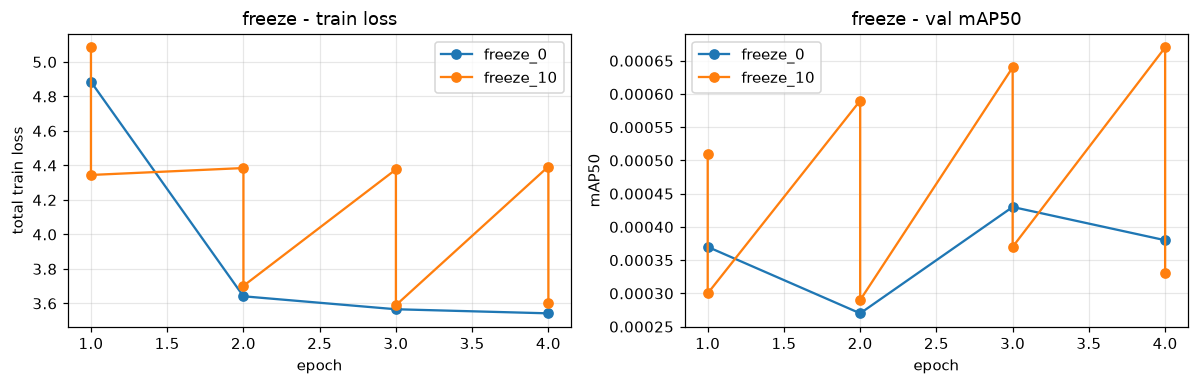

In [7]:
# Backbone freezing on D-Fire.
# CAVEAT: this starts from COCO weights, not stage-1 weights, because stage 1
# does not exist yet. It therefore tests "does freezing hinder adaptation to
# D-Fire", NOT the actual question ("does freezing prevent forgetting FASDD
# features"). Directional only.
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for name in summary.query("group == 'freeze' and ok")["name"]:
    df = load(name)
    ax[0].plot(df["epoch"], total_train_loss(df), marker="o", label=name)
    ax[1].plot(df["epoch"], df["metrics/mAP50(B)"], marker="o", label=name)
ax[0].set(xlabel="epoch", ylabel="total train loss", title="freeze - train loss")
ax[1].set(xlabel="epoch", ylabel="mAP50", title="freeze - val mAP50")
for a in ax:
    a.legend()
plt.tight_layout()
summary.query("group == 'freeze'")[["name", "wall_s", "peak_vram_gb"]]

## 7. Epoch budget and `close_mosaic`

Run on `fasdd_big` (3,000 images) over 20 epochs at the production config.

**Findings:** both arms are still improving through epoch 17-19, so short
budgets clearly leave gains on the table — though this cannot settle 20 vs 30
for the real run (~28x more images per epoch). And `close_mosaic=10` (the
default) wins, pulling ahead from epoch 11-13 — exactly when mosaic switches
off at epoch 10 and it starts training on clean images. Both defaults kept.

Note this indirectly supports the section 8 mosaic retraction:
mosaic-then-disable beats never-mosaic, so mosaic's regularisation *is*
helping — it just needs turning off at the end, which the default does.

  epoch_budget_cm10    final=0.6897  peak=0.6992 @ epoch 19
  epoch_budget_cm0     final=0.6703  peak=0.6714 @ epoch 19


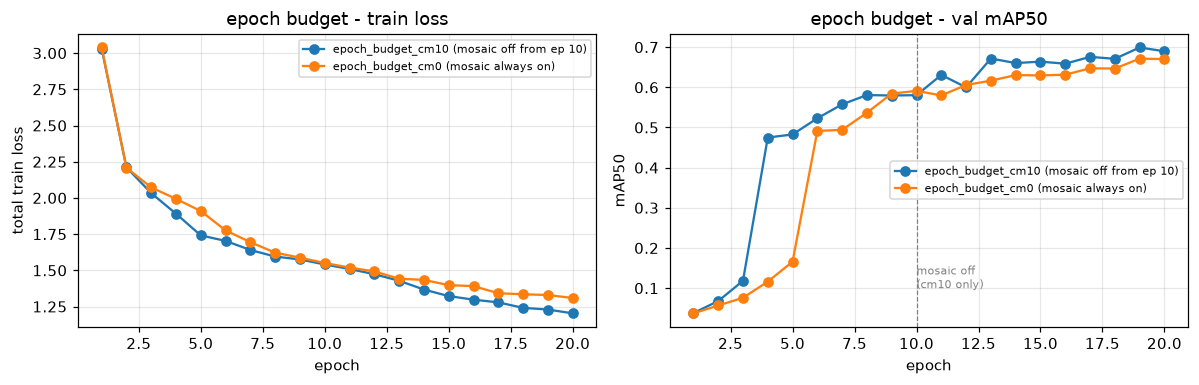

In [8]:
# Epoch budget + close_mosaic, on the LARGER fasdd_big slice (3,000 images vs
# the usual 1,200) at the production config (imgsz 640, batch 16, lr0 3e-4).
# Two questions in one pair of runs: is mAP50 still improving at epoch 20
# (epoch-count signal), and does disabling mosaic for the last 10 epochs help
# (close_mosaic signal)?
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for name in summary.query("group == 'epoch_budget' and ok")["name"]:
    df = load(name)
    lbl = f"{name} (mosaic off from ep 10)" if name.endswith("cm10") else f"{name} (mosaic always on)"
    ax[0].plot(df["epoch"], total_train_loss(df), marker="o", label=lbl)
    ax[1].plot(df["epoch"], df["metrics/mAP50(B)"], marker="o", label=lbl)
ax[1].axvline(10, color="grey", ls="--", lw=0.8)
ax[1].annotate("mosaic off\n(cm10 only)", xy=(10, 0.1), fontsize=7, color="grey")
ax[0].set(xlabel="epoch", ylabel="total train loss", title="epoch budget - train loss")
ax[1].set(xlabel="epoch", ylabel="mAP50", title="epoch budget - val mAP50")
for a in ax:
    a.legend(fontsize=7)
plt.tight_layout()

for name in summary.query("group == 'epoch_budget' and ok")["name"]:
    d = load(name)["metrics/mAP50(B)"]
    print(f"  {name:20} final={d.iloc[-1]:.4f}  peak={d.max():.4f} @ epoch {d.idxmax()+1}")

## 8. LR schedule shape, and mosaic on D-Fire

Two A/B pairs, both of which ended in "keep the default":

- **`cos_lr`**: linear (default) 0.6102 vs cosine 0.6079 — no meaningful
  difference. This pair also produced the suite's best noise measurement: a
  **-0.25 mAP50 gap at epoch 6** between near-identical configs.
- **mosaic on D-Fire**: mosaic-off finished ahead (0.636 vs 0.621) and won
  12/14 epochs, which initially read as "disable mosaic for stage 2".
  **Retracted** — the gap collapses from +0.314 (epoch 5) to +0.015 (epoch
  14), i.e. mosaic-on catching up, and the final gap sits below the noise
  floor above. Stage 2 runs 30 epochs, double this probe. Same truncation
  trap as the 1280 resolution probe in section 5.

coslr max |per-epoch gap| = 0.2506 (at epoch 6) <- the noise floor
mosaic gap: epoch 5 +0.3136 -> epoch 14 +0.0151 (collapsing -> truncation artefact, see docs sec 5.7)


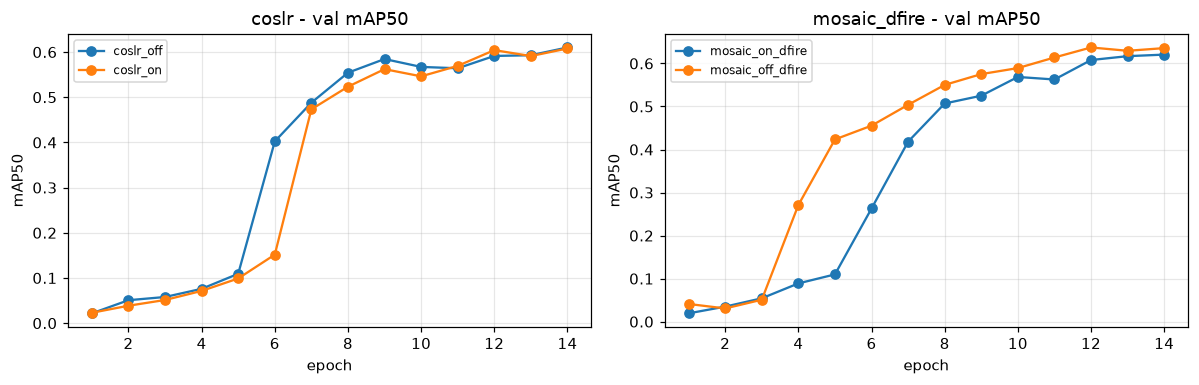

In [9]:
# Two small A/B pairs: LR schedule shape, and mosaic on D-Fire.
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for g, a in [("coslr", ax[0]), ("mosaic_dfire", ax[1])]:
    for name in summary.query("group == @g and ok")["name"]:
        df = load(name)
        a.plot(df["epoch"], df["metrics/mAP50(B)"], marker="o", label=name)
    a.set(xlabel="epoch", ylabel="mAP50", title=f"{g} - val mAP50")
    a.legend(fontsize=8)
plt.tight_layout()

# The epoch-6 coslr gap is the single best noise measurement in the suite:
# two near-identical configs differing by ~0.25 mAP50 in one epoch.
c_off, c_on = load("coslr_off")["metrics/mAP50(B)"], load("coslr_on")["metrics/mAP50(B)"]
print(f"coslr max |per-epoch gap| = {(c_on - c_off).abs().max():.4f} "
      f"(at epoch {(c_on - c_off).abs().idxmax()+1}) <- the noise floor")
m_on, m_off = load("mosaic_on_dfire")["metrics/mAP50(B)"], load("mosaic_off_dfire")["metrics/mAP50(B)"]
print(f"mosaic gap: epoch 5 {(m_off-m_on).iloc[4]:+.4f} -> epoch 14 {(m_off-m_on).iloc[-1]:+.4f} "
      f"(collapsing -> truncation artefact, see docs sec 5.7)")

## 9. Generalisation gap

`val_loss - train_loss` per epoch. Rising = memorising rather than
generalising. Over 4 epochs this is a weak signal, but a *sharp* divergence
would still be worth catching before a 15 h run.

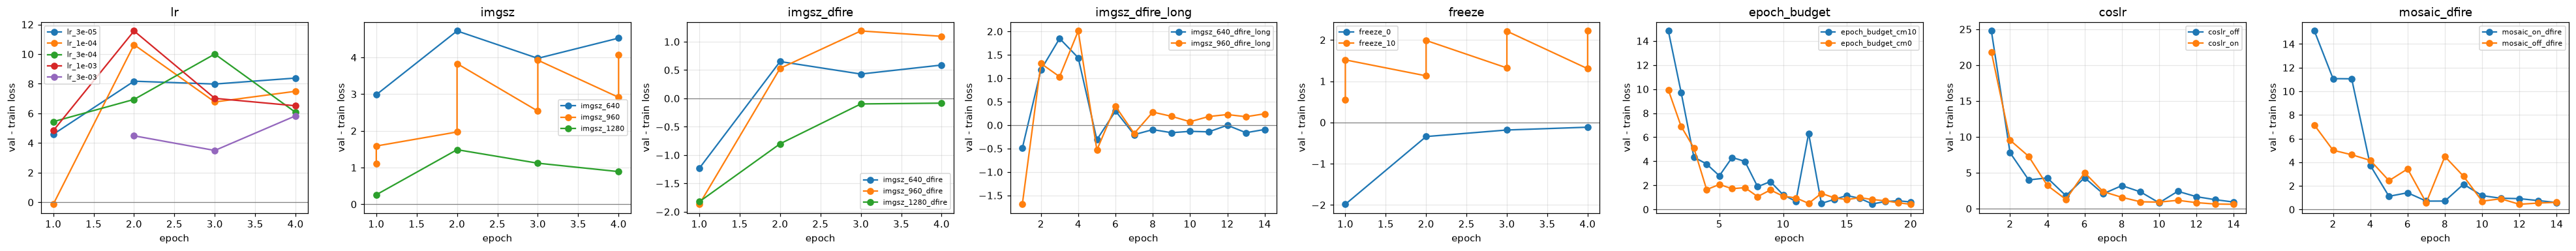

In [10]:
# Train vs val loss - the overfitting signal. A widening gap means the model is
# memorising rather than generalising.
groups = [g for g in ("lr", "imgsz", "imgsz_dfire", "imgsz_dfire_long", "freeze",
                      "epoch_budget", "coslr", "mosaic_dfire")
          if (summary["group"] == g).any()]
fig, ax = plt.subplots(1, len(groups), figsize=(4.5 * len(groups), 3.6), squeeze=False)
for i, g in enumerate(groups):
    for name in summary.query("group == @g and ok")["name"]:
        df = load(name)
        ax[0][i].plot(df["epoch"], total_val_loss(df) - total_train_loss(df),
                      marker="o", label=name)
    ax[0][i].axhline(0, color="grey", lw=0.8)
    ax[0][i].set(xlabel="epoch", ylabel="val - train loss", title=f"{g}")
    ax[0][i].legend(fontsize=7)
plt.tight_layout()